<a href="https://colab.research.google.com/github/skywalker0803r/CFB/blob/main/%E7%89%B9%E5%BE%B5%E7%AF%A9%E9%81%B8%E5%BE%8C%E5%BB%BA%E6%A8%A1Y2_%E7%A7%BB%E9%99%A4%E6%95%B8%E5%80%BC%E6%81%86%E5%AE%9A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import joblib
features = joblib.load('features2.pkl')
features

['MLUT4_FT-957',
 'MLUT4_FT-956',
 'MLUT4_FIC-231C',
 'MLUT4_FIC-231B',
 'MLUT4_PDT-232',
 'MLUT4_PIC-233',
 'MLUT4_TE-252D',
 'MLUT4_FIC-231A',
 'MLUT4_AIA792101B',
 'MLUT4_IT-E7925B',
 'MLUT4_RT-091',
 'MLUT4_AT-232A',
 'MLUT4_FT-792020',
 'MLUT4_FQ-239',
 'MLUT4_TE-251H',
 'MLUT4_TE-252I',
 'MLUT4_IT-E7925A',
 'MLUT4_FIC-233',
 'MLUT4_FT-V004',
 'MLUT4_PT-231',
 'MLUT4_FT-232',
 'MLUT4_FQ-205',
 'MLUT4_ZT-232',
 'MLUT4_AT-237',
 'MLUT4_FT-951AB']

In [2]:
from google.colab import drive
import numpy as np
drive.mount('/content/drive')
import pandas as pd
df = pd.read_excel('/content/drive/MyDrive/脫硫劑優化改善/20240916-CFB2脫硫劑優化改善.xlsx')
col = df.columns
df = df.iloc[1:,:]
df.columns = col
df = df.set_index('Unnamed: 0')
df.index.name = 'datetime'
for i in df.columns:
  df[i] = pd.to_numeric(df[i], errors='coerce')
df = df.replace([np.inf, -np.inf], np.nan)
df

Mounted at /content/drive


/usr/local/lib/python3.11/dist-packages/pandas/core/indexes/base.py:7588: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)


,MLUT4_AIA792101A,MLUT4_AIA792101B,MLUT4_AIC-232B,MLUT4_AT-232A,MLUT4_AT-237,MLUT4_AT-240,MLUT4_AT-240A,MLUT4_FIC-231A,MLUT4_FIC-231B,MLUT4_FIC-231C,...,MLUT4_TE-252F,MLUT4_TE-252G,MLUT4_TE-252H,MLUT4_TE-252I,MLUT4_ZT-231,MLUT4_ZT-232,DeSOx_1st,DeSOx_2nd,前爐SOx濃度,鈣硫比
datetime,,,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00,5.540932,6.800000,67.034424,151.208024,9.623605,8.619934,8.619934,20.605973,0.000000,17.456094,...,876.984866,845.297084,845.703201,876.997523,59.200001,15.000000,0.969941,0.871410,2230.093232,2.223152
2024-01-01 00:05:00,5.533478,6.800000,66.662524,150.811453,9.616252,8.147002,8.147002,20.181020,0.000000,17.449118,...,875.326466,846.587071,844.102850,877.381060,59.200001,15.000000,0.969979,0.877787,2220.527929,2.220789
2024-01-01 00:10:00,5.526025,6.800000,64.320729,151.708113,9.608899,8.247992,8.247992,20.200619,0.000000,17.442142,...,875.675699,845.374599,843.500123,877.897600,59.200001,15.000000,0.971249,0.871768,2237.129686,2.217612
2024-01-01 00:15:00,5.518571,6.801543,64.840762,151.283528,9.600898,7.605820,7.605820,20.220218,0.000000,17.571883,...,875.435828,845.100450,842.910508,874.888616,59.200001,15.000000,0.970896,0.882700,2227.895501,2.214444
2024-01-01 00:20:00,5.511117,6.819977,64.390831,150.994896,9.581994,6.110485,6.110485,20.549012,0.000000,17.339679,...,875.245400,846.058978,844.200021,878.416710,59.200001,15.000000,0.970878,0.905103,2211.052236,2.211285
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-09-15 23:35:00,6.258452,5.140339,114.166438,209.520746,9.360355,13.105704,13.105704,12.795748,11.854892,12.842200,...,916.635699,889.885541,906.016252,870.865216,100.000000,26.103367,0.945172,0.885205,2082.274527,3.928554
2024-09-15 23:40:00,6.284992,5.166336,106.669841,208.177318,9.280099,9.903673,9.903673,12.797045,11.862273,12.823741,...,914.065610,889.042164,904.255862,869.007829,100.000000,26.093265,0.948517,0.907156,2071.948976,3.927730
2024-09-15 23:45:00,6.232171,5.225976,104.663595,211.564232,9.359701,9.345572,9.345572,12.798342,11.880556,12.842696,...,913.978871,890.439554,903.442876,867.712970,100.000000,26.100000,0.949882,0.910708,2088.339754,3.928170


In [3]:

import pandas as pd

# 假設 df 是你的原始資料表，包含時間、MLUT4_AT-237、MLUT4_AT-240 欄位
def remove_constant_segments(df, column, threshold=5):
    # 找出相同值的連續段落
    const_groups = (df[column] != df[column].shift()).cumsum()
    group_sizes = df.groupby(const_groups)[column].transform('size')
    is_constant = group_sizes >= threshold
    is_same_value = df[column] == df[column].shift()
    # 建立 mask：該段是恆定且筆數 >= threshold
    to_remove = is_constant & is_same_value
    return df[~to_remove]

# 同時處理兩個欄位
print(df.shape)
df_clean = remove_constant_segments(df, 'MLUT4_AT-237')
df_clean = remove_constant_segments(df_clean, 'MLUT4_AT-240')
print(df_clean.shape)
df = df_clean

(74592, 60)
(50488, 60)


In [4]:
y_col = ['DeSOx_2nd']

In [5]:
df[features+y_col]

,MLUT4_FT-957,MLUT4_FT-956,MLUT4_FIC-231C,MLUT4_FIC-231B,MLUT4_PDT-232,MLUT4_PIC-233,MLUT4_TE-252D,MLUT4_FIC-231A,MLUT4_AIA792101B,MLUT4_IT-E7925B,...,MLUT4_IT-E7925A,MLUT4_FIC-233,MLUT4_FT-V004,MLUT4_PT-231,MLUT4_FT-232,MLUT4_FQ-205,MLUT4_ZT-232,MLUT4_AT-237,MLUT4_FT-951AB,DeSOx_2nd
datetime,,,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00,3917.594740,3992.840799,17.456094,0.000000,78.370626,971.286903,861.535652,20.605973,6.800000,17.254982,...,13.302897,179.388400,0.00,1393.855901,359.664266,357.373726,15.000000,9.623605,99.231466,0.871410
2024-01-01 00:05:00,3917.320459,3988.473250,17.449118,0.000000,79.258313,969.395192,860.299612,20.181020,6.800000,17.324028,...,13.276501,179.313536,0.00,1393.743589,359.556551,356.975651,15.000000,9.616252,100.033768,0.877787
2024-01-01 00:10:00,3913.623750,3984.113830,17.442142,0.000000,77.719304,969.959118,858.073290,20.200619,6.800000,17.168178,...,13.300000,179.519411,0.00,1393.414400,355.172410,355.650485,15.000000,9.608899,99.932670,0.871768
2024-01-01 00:15:00,3929.257511,3984.936436,17.571883,0.000000,78.297800,971.875751,858.422111,20.220218,6.801543,17.308134,...,13.300000,179.465741,0.00,1393.990782,355.875036,356.219519,15.000000,9.600898,99.831572,0.882700
2024-01-01 00:20:00,3914.198450,3985.762194,17.339679,0.000000,78.501901,971.082502,859.316649,20.549012,6.819977,17.241191,...,13.275966,179.344261,0.00,1394.205901,356.333792,357.409226,15.000000,9.581994,100.181768,0.905103
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-09-15 23:35:00,2639.985169,2630.971265,12.842200,11.854892,55.084016,954.066222,928.560012,12.795748,5.140339,15.681699,...,12.774718,227.094066,1.87,1361.905776,243.293496,307.745677,26.103367,9.360355,97.405392,0.885205
2024-09-15 23:40:00,2644.140047,2637.921800,12.823741,11.862273,54.970461,956.169561,926.909370,12.797045,5.166336,15.637485,...,12.769719,226.873818,1.87,1364.378553,241.649951,308.234169,26.093265,9.280099,97.528753,0.907156
2024-09-15 23:45:00,2636.322947,2635.895821,12.842696,11.880556,54.838819,958.502714,926.152206,12.798342,5.225976,15.715107,...,12.744950,227.212922,1.87,1368.033108,244.585288,304.988863,26.100000,9.359701,98.286113,0.910708


# 刪除離群值

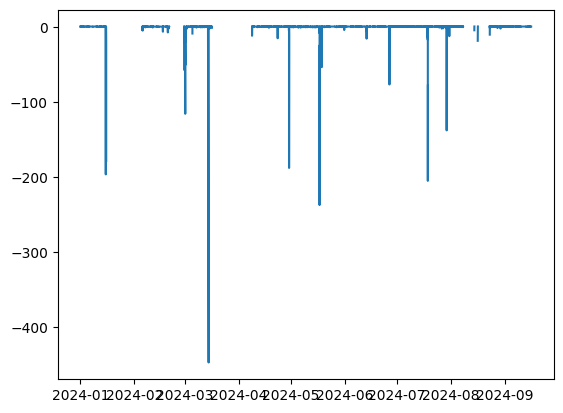

In [6]:
import matplotlib.pyplot as plt
plt.plot(df.index,df['DeSOx_2nd'])
plt.show()

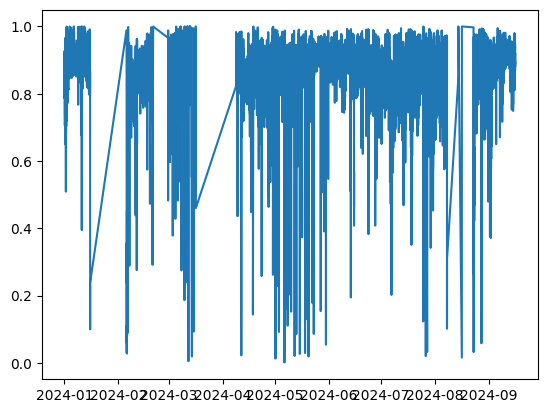

In [7]:
data = df[df['DeSOx_2nd']>0]
plt.plot(data.index,data['DeSOx_2nd'])
plt.show()

# 馬氏距離刪除離群值

In [8]:
import pandas as pd
import numpy as np
from scipy.stats import chi2

def del_outliers_mahalanobis(df):
  mean_vec = df.mean().values
  cov_matrix = np.cov(df.values, rowvar=False)
  inv_cov_matrix = np.linalg.inv(cov_matrix)

  # Step 2: 計算每筆資料的馬氏距離
  def mahalanobis(x, mean, inv_cov):
      diff = x - mean
      return np.sqrt(diff.T @ inv_cov @ diff)

  # 計算所有樣本的距離
  distances = df.apply(lambda row: mahalanobis(row.values, mean_vec, inv_cov_matrix), axis=1)

  # Step 3: 決定閾值，例如卡方分布下95%置信區間的臨界值（自由度=2因為是兩欄）
  threshold = np.sqrt(chi2.ppf(0.99, df=2))

  # Step 4: 過濾掉離群樣本
  df_clean = df[distances < threshold]

  # 如果你想看哪些是離群值
  outliers = df[distances >= threshold]

  return df_clean

In [9]:
#for i in features:
#  data = data.loc[del_outliers_mahalanobis(data[[i,'DeSOx_2nd']]).index,:]
#  plt.scatter(data[i],data['DeSOx_2nd'])
#  plt.show()

# 標準化

In [10]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data.loc[:,features] = scaler.fit_transform(data.loc[:,features])
data

<ipython-input-10-1300848106>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[:,features] = scaler.fit_transform(data.loc[:,features])


,MLUT4_AIA792101A,MLUT4_AIA792101B,MLUT4_AIC-232B,MLUT4_AT-232A,MLUT4_AT-237,MLUT4_AT-240,MLUT4_AT-240A,MLUT4_FIC-231A,MLUT4_FIC-231B,MLUT4_FIC-231C,...,MLUT4_TE-252F,MLUT4_TE-252G,MLUT4_TE-252H,MLUT4_TE-252I,MLUT4_ZT-231,MLUT4_ZT-232,DeSOx_1st,DeSOx_2nd,前爐SOx濃度,鈣硫比
datetime,,,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00,5.540932,0.650788,67.034424,-1.009711,0.398730,8.619934,8.619934,1.643712,-1.785745,1.083941,...,876.984866,845.297084,845.703201,0.134649,59.200001,-1.405324,0.969941,0.871410,2230.093232,2.223152
2024-01-01 00:05:00,5.533478,0.650788,66.662524,-1.020391,0.393937,8.147002,8.147002,1.528418,-1.785745,1.081920,...,875.326466,846.587071,844.102850,0.141794,59.200001,-1.405324,0.969979,0.877787,2220.527929,2.220789
2024-01-01 00:10:00,5.526025,0.650788,64.320729,-0.996243,0.389143,8.247992,8.247992,1.533735,-1.785745,1.079900,...,875.675699,845.374599,843.500123,0.151417,59.200001,-1.405324,0.971249,0.871768,2237.129686,2.217612
2024-01-01 00:15:00,5.518571,0.651704,64.840762,-1.007677,0.383927,7.605820,7.605820,1.539052,-1.785745,1.117482,...,875.435828,845.100450,842.910508,0.095361,59.200001,-1.405324,0.970896,0.882700,2227.895501,2.214444
2024-01-01 00:20:00,5.511117,0.662648,64.390831,-1.015450,0.371603,6.110485,6.110485,1.628258,-1.785745,1.050219,...,875.245400,846.058978,844.200021,0.161087,59.200001,-1.405324,0.970878,0.905103,2211.052236,2.211285
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-09-15 23:35:00,6.258452,-0.334530,114.166438,0.560724,0.227108,13.105704,13.105704,-0.475283,0.548278,-0.252579,...,916.635699,889.885541,906.016252,0.020407,100.000000,0.213541,0.945172,0.885205,2082.274527,3.928554
2024-09-15 23:40:00,6.284992,-0.319096,106.669841,0.524544,0.174786,9.903673,9.903673,-0.474931,0.549731,-0.257926,...,914.065610,889.042164,904.255862,-0.014195,100.000000,0.212068,0.948517,0.907156,2071.948976,3.927730
2024-09-15 23:45:00,6.232171,-0.283689,104.663595,0.615758,0.226681,9.345572,9.345572,-0.474579,0.553331,-0.252435,...,913.978871,890.439554,903.442876,-0.038317,100.000000,0.213050,0.949882,0.910708,2088.339754,3.928170


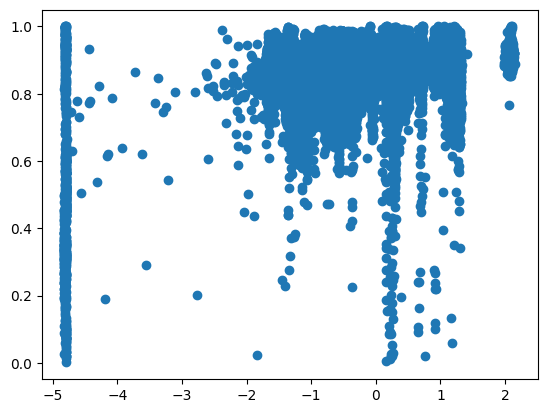

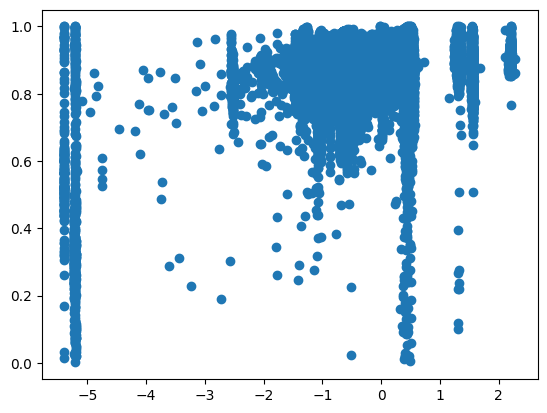

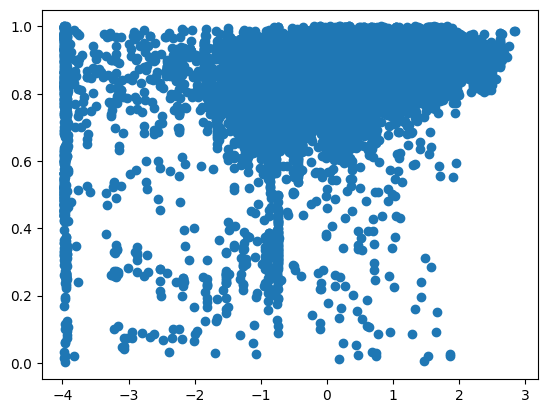

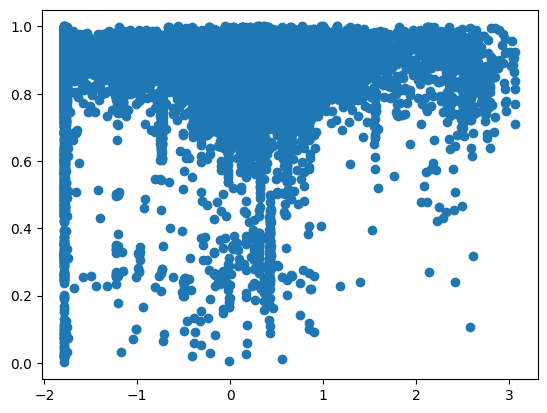

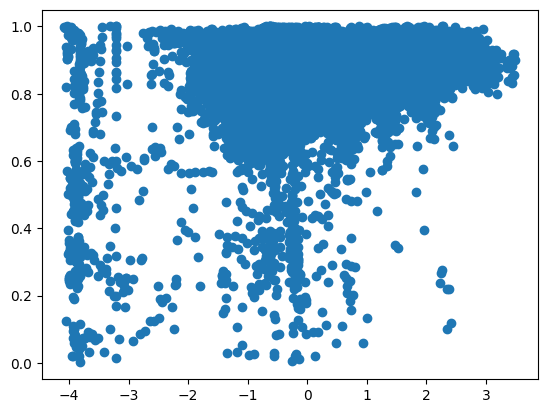

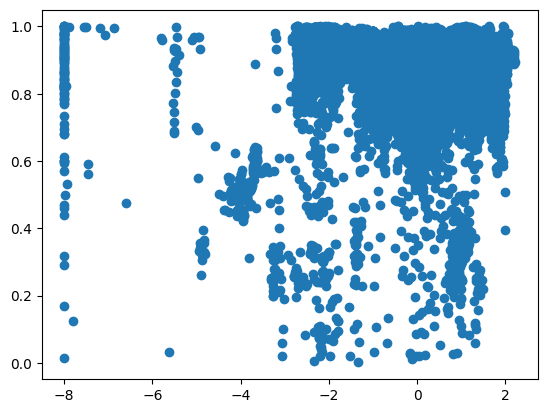

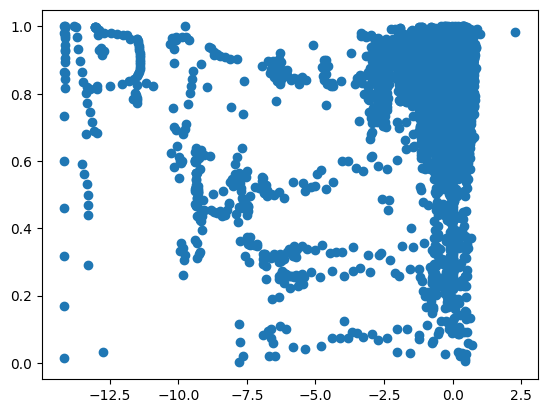

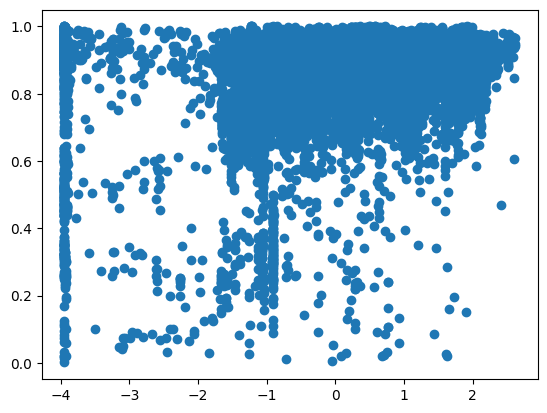

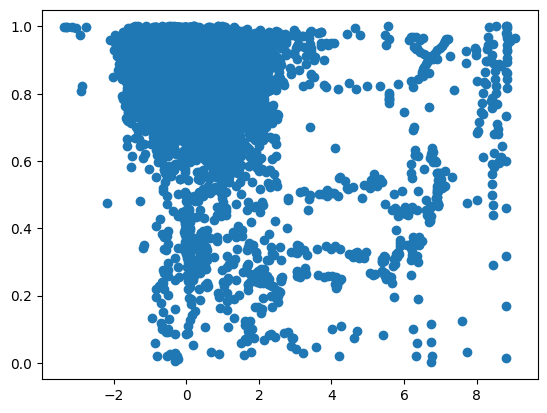

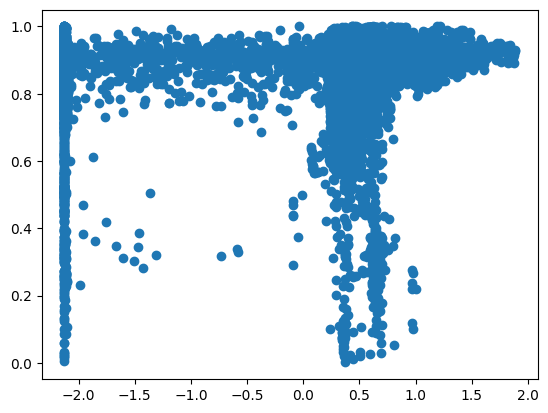

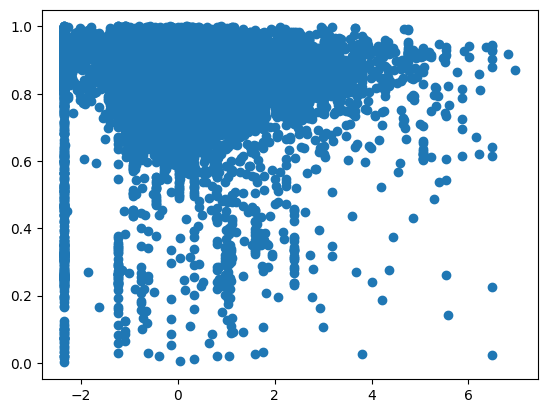

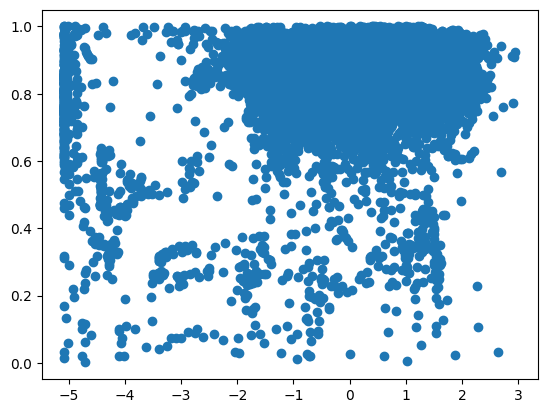

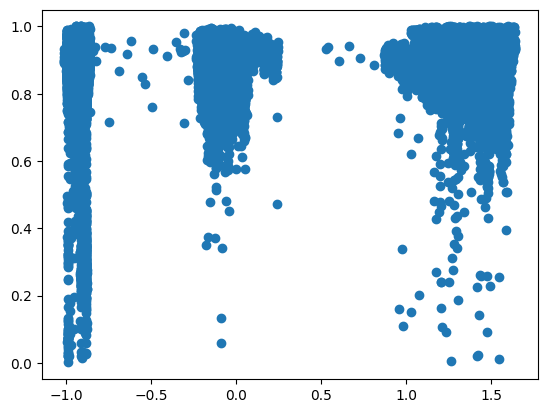

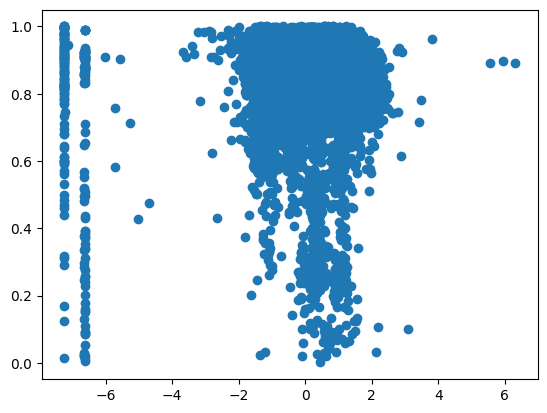

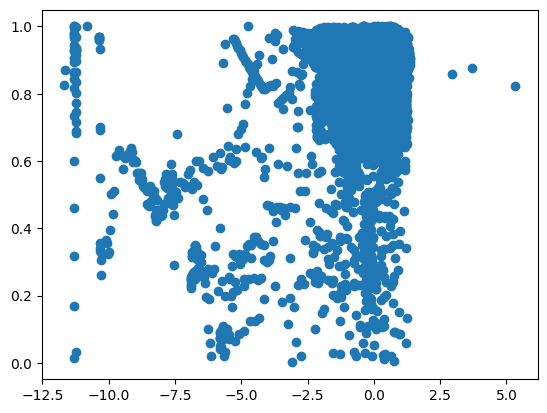

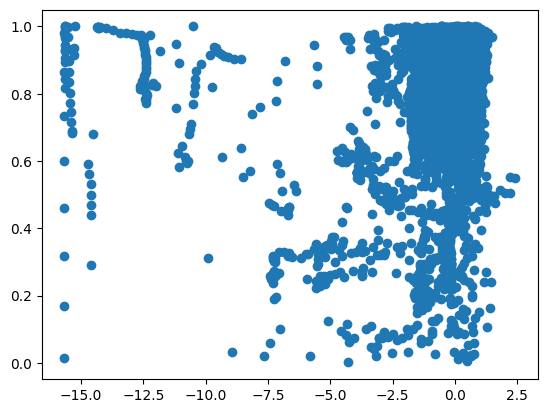

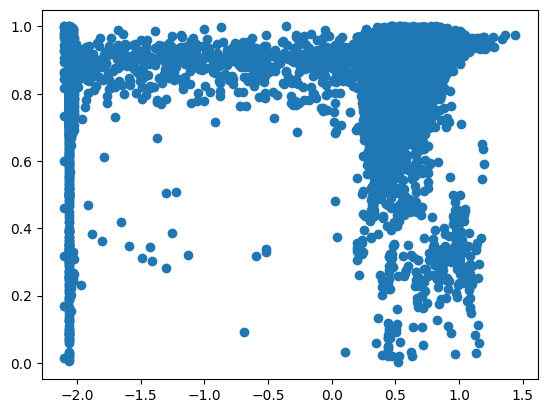

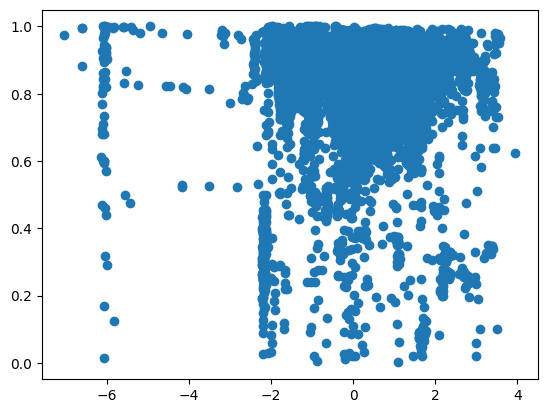

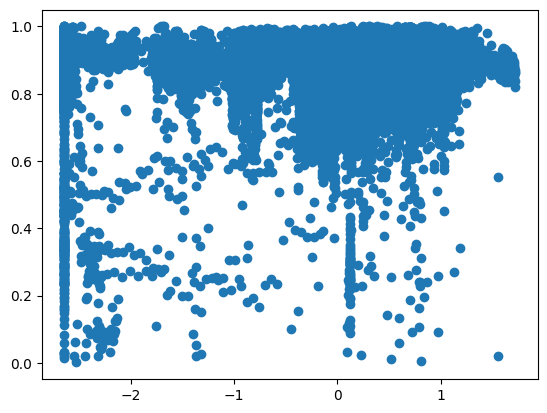

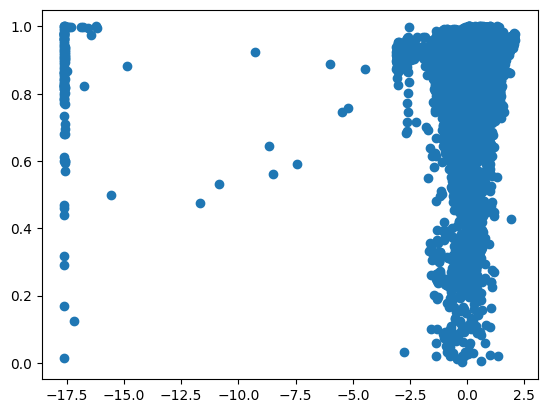

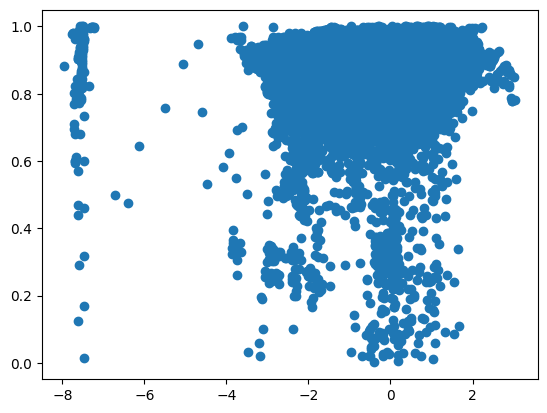

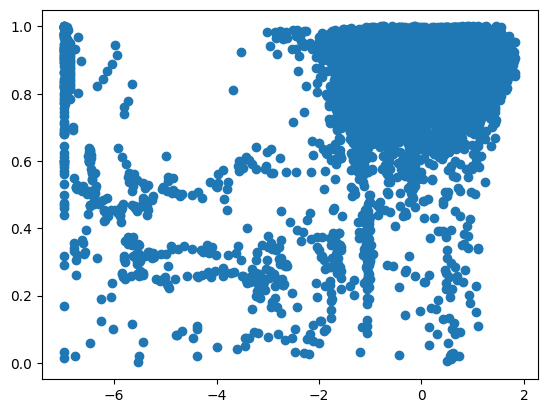

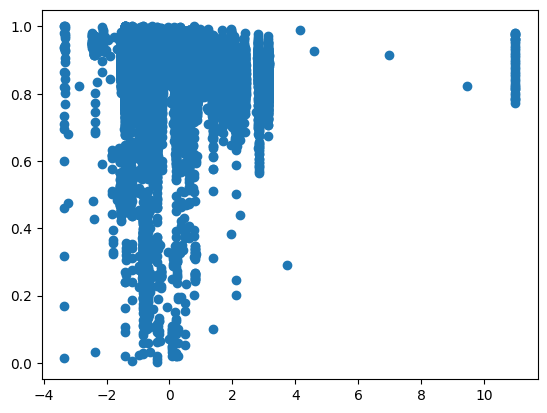

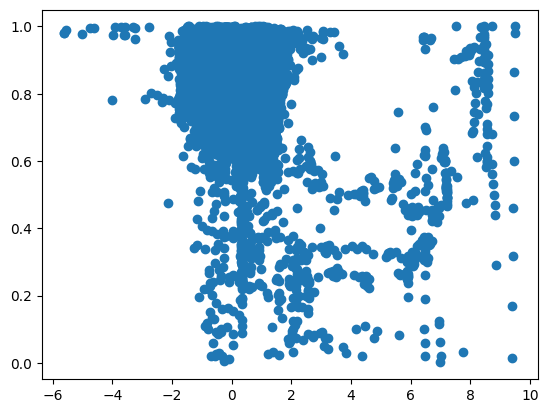

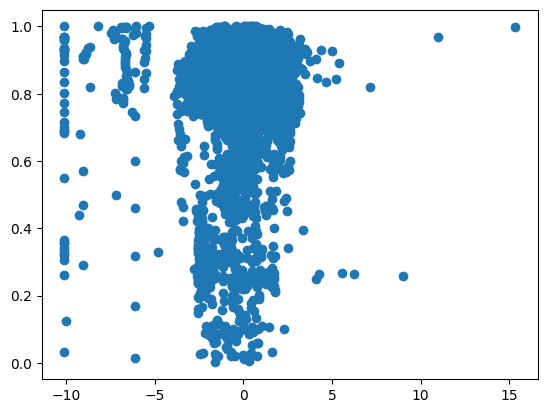

In [11]:
for i in features:
  plt.scatter(data[i],data['DeSOx_2nd'])
  plt.show()

# 線性回歸

In [12]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error

X,Y = data[features],data['DeSOx_2nd']

# 2. 資料切分：訓練 80% / 測試 20%
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# 3. 建立並訓練線性回歸模型
model = LinearRegression()
model.fit(X_train, y_train)

# 4. 預測
y_pred = model.predict(X_test)

# 5. 評估
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred)*100

res = pd.DataFrame()
res['R2'] = [r2]
res['RMSE'] = [rmse]
res['MAPE'] = [mape]
res_reg = res
res_reg

,R2,RMSE,MAPE
0,0.427763,0.067051,8.546718


# Ridge 回歸

In [13]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error

# 2. 切分資料為訓練與測試集
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# 3. 建立並訓練 Ridge 回歸模型
ridge = Ridge(alpha=1.0)  # 可嘗試不同的 alpha，例如 0.1, 1, 10
ridge.fit(X_train, y_train)

# 4. 預測
y_pred = ridge.predict(X_test)

# 5. 評估
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred)*100

res = pd.DataFrame()
res['R2'] = [r2]
res['RMSE'] = [rmse]
res['MAPE'] = [mape]
res_ridge = res
res_ridge


,R2,RMSE,MAPE
0,0.427756,0.067052,8.546762


# Lasso 回歸

In [14]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error

# 2. 資料切分
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# 3. 建立 Lasso 模型並訓練
lasso = Lasso(alpha=0.1)  # alpha 越大，壓縮越強，更多係數會變 0
lasso.fit(X_train, y_train)

# 4. 預測
y_pred = lasso.predict(X_test)

# 5. 評估
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred)*100

res = pd.DataFrame()
res['R2'] = [r2]
res['RMSE'] = [rmse]
res['MAPE'] = [mape]
res_lasso = res
res_lasso


,R2,RMSE,MAPE
0,-0.000033,0.088639,11.083204


In [15]:
import numpy as np
import pandas as pd
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error

# 2. 資料切分
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# 3. 建立 ElasticNet 模型並訓練
elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5)  # l1_ratio=0.5 表示 L1:L2 = 1:1
elastic_net.fit(X_train, y_train)

# 4. 預測
y_pred = elastic_net.predict(X_test)

# 5. 評估
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred)*100

res = pd.DataFrame()
res['R2'] = [r2]
res['RMSE'] = [rmse]
res['MAPE'] = [mape]
res_ElasticNet = res
res_ElasticNet


,R2,RMSE,MAPE
0,-0.000033,0.088639,11.083204


In [16]:
import numpy as np
import pandas as pd
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error

# 2. 訓練/測試資料切分
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# 3. 建立並訓練 PLS 模型（選擇主成分數目）
pls = PLSRegression(n_components=2)
pls.fit(X_train, y_train)

# 4. 預測
y_pred = pls.predict(X_test).ravel()  # .ravel() 將輸出轉成一維陣列

# 5. 評估
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred)*100

res = pd.DataFrame()
res['R2'] = [r2]
res['RMSE'] = [rmse]
res['MAPE'] = [mape]
res_PLS = res
res_PLS


,R2,RMSE,MAPE
0,0.351349,0.071388,9.074702


In [17]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error
from tqdm import tqdm

# 2. 訓練/測試資料切分
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=100, warm_start=True, random_state=42)
rf.fit(X_train, y_train)

# 4. 預測
y_pred = rf.predict(X_test)

# 5. 評估
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred)*100

res = pd.DataFrame()
res['R2'] = [r2]
res['RMSE'] = [rmse]
res['MAPE'] = [mape]
res_rf = res
res_rf


,R2,RMSE,MAPE
0,0.833395,0.03618,4.010976


In [18]:
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error

# 2. 資料切分
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# 3. 建立並訓練 XGBoost 回歸模型
xgb = XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)

# 4. 預測
y_pred = xgb.predict(X_test)

# 5. 評估
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred)*100

res = pd.DataFrame()
res['R2'] = [r2]
res['RMSE'] = [rmse]
res['MAPE'] = [mape]
res_xgb = res
res_xgb


,R2,RMSE,MAPE
0,0.807303,0.03891,4.408559


In [19]:
import numpy as np
import pandas as pd
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler

# 2. 資料切分
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# 4. 建立並訓練 SVR 模型
svr = SVR()
svr.fit(X_train,y_train)

# 5. 預測（記得反標準化）
y_pred = svr.predict(X_test)

# 5. 評估
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = mean_absolute_percentage_error(y_test, y_pred)*100

res = pd.DataFrame()
res['R2'] = [r2]
res['RMSE'] = [rmse]
res['MAPE'] = [mape]
res_svr = res
res_svr


,R2,RMSE,MAPE
0,0.703817,0.048239,5.952945


In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split
import numpy as np

# 切分資料
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# 轉成Tensor
X_train_t = torch.tensor(X_train.values, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)
X_test_t = torch.tensor(X_test.values, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

# 2. 定義 MLP 模型
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super(MLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim//2),
            nn.ReLU(),
            nn.Linear(hidden_dim//2, 1)
        )
    def forward(self, x):
        return self.net(x)

model = MLP(input_dim=len(features))

# 3. 損失函數與優化器
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# 4. 訓練迴圈
n_epochs = 300
for epoch in range(n_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_t)
    loss = criterion(outputs, y_train_t)
    loss.backward()
    optimizer.step()

    if (epoch+1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{n_epochs}], Loss: {loss.item():.4f}")

# 5. 測試與評估
model.eval()
with torch.no_grad():
    y_pred_t = model(X_test_t).view(-1).numpy()

r2 = r2_score(y_test, y_pred_t)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_t))
mape = mean_absolute_percentage_error(y_test, y_pred_t)

res = pd.DataFrame()
res['R2'] = [r2]
res['RMSE'] = [rmse]
res['MAPE'] = [mape]
res_mlp = res
res_mlp


Epoch [5/300], Loss: 0.2324
Epoch [10/300], Loss: 0.0615
Epoch [15/300], Loss: 0.0375
Epoch [20/300], Loss: 0.0246
Epoch [25/300], Loss: 0.0198
Epoch [30/300], Loss: 0.0166
Epoch [35/300], Loss: 0.0131
Epoch [40/300], Loss: 0.0107
Epoch [45/300], Loss: 0.0088
Epoch [50/300], Loss: 0.0076
Epoch [55/300], Loss: 0.0068
Epoch [60/300], Loss: 0.0062
Epoch [65/300], Loss: 0.0056
Epoch [70/300], Loss: 0.0052
Epoch [75/300], Loss: 0.0049
Epoch [80/300], Loss: 0.0046
Epoch [85/300], Loss: 0.0044
Epoch [90/300], Loss: 0.0042
Epoch [95/300], Loss: 0.0040
Epoch [100/300], Loss: 0.0039
Epoch [105/300], Loss: 0.0037
Epoch [110/300], Loss: 0.0036
Epoch [115/300], Loss: 0.0035
Epoch [120/300], Loss: 0.0034
Epoch [125/300], Loss: 0.0033
Epoch [130/300], Loss: 0.0033
Epoch [135/300], Loss: 0.0032
Epoch [140/300], Loss: 0.0031
Epoch [145/300], Loss: 0.0031
Epoch [150/300], Loss: 0.0030
Epoch [155/300], Loss: 0.0030
Epoch [160/300], Loss: 0.0029
Epoch [165/300], Loss: 0.0029
Epoch [170/300], Loss: 0.0028


,R2,RMSE,MAPE
0,0.698045,0.048707,0.060952


In [21]:
res = pd.concat([res_reg,res_ridge,res_lasso,res_ElasticNet,res_PLS,res_rf,res_xgb,res_svr,res_mlp])
res.index = ['reg','ridge','lasso','elastic','PLS','rf','xgb','svr','mlp']
res

,R2,RMSE,MAPE
reg,0.427763,0.067051,8.546718
ridge,0.427756,0.067052,8.546762
lasso,-0.000033,0.088639,11.083204
elastic,-0.000033,0.088639,11.083204
PLS,0.351349,0.071388,9.074702
rf,0.833395,0.036180,4.010976
xgb,0.807303,0.038910,4.408559
svr,0.703817,0.048239,5.952945
mlp,0.698045,0.048707,0.060952


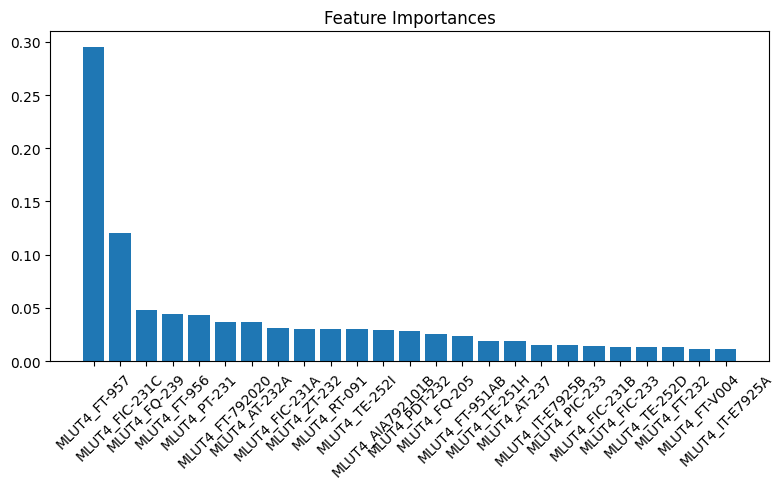

In [22]:
import matplotlib.pyplot as plt

# 排序特徵重要度
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

# 畫圖
plt.figure(figsize=(8, 5))
plt.title("Feature Importances")
plt.bar(range(X.shape[1]), importances[indices], align='center')
plt.xticks(range(X.shape[1]), [features[i] for i in indices], rotation=45)
plt.tight_layout()
plt.show()


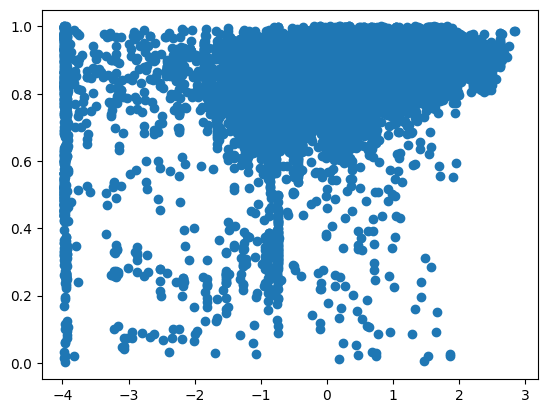

In [23]:
plt.scatter(data['MLUT4_FIC-231C'],data['DeSOx_2nd'])